#  Projet Machine Learning avec <a href="https://cran.r-project.org/"><img src="https://cran.r-project.org/Rlogo.svg" style="max-width: 40px; display: inline" alt="R"/></a>

## 1. Analyse exploratoire des données

In [24]:
#install.packages(c("GGally","plotly","corrplot","reshape2","FactoMineR","factoextra","glmnet","ggfortify","pROC","ROCR"), dependencies = TRUE)


In [25]:
#install.packages("ggplot2", repos = "https://cloud.r-project.org/")


In [26]:
#install.packages("caret")

In [27]:
#install.packages(tidyverse)

In [28]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(MASS) # chargement des librairies
library(class) # pour kNN

# Lecture des données 

In [29]:
# Lecture des données
path <- ""
health <- read.csv(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Premières lignes du jeu de données
head(health)
# Vérification du contenu
summary(health)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

## Changement du type des variables qualitatives en facteur

In [30]:
# Changement du type des variables qualitatives en facteur
health[, "Gender"] <- as.factor(health[, "Gender"])
health[, "Smoking_Status"] <- as.factor(health[, "Smoking_Status"])
health[, "Alcohol_Consumption"] <- as.factor(health[, "Alcohol_Consumption"])
health[, "Physical_Activity_Level"] <- as.factor(health[, "Physical_Activity_Level"])
health[, "Family_History"] <- as.factor(health[, "Family_History"])
health[, "Stress_Level"] <- as.factor(health[, "Stress_Level"])
health[, "Heart_Disease_Risk"] <- as.factor(health[, "Heart_Disease_Risk"])
health[, "Sleep_Hours"] <- as.factor(health[, "Sleep_Hours"])


In [31]:
summary(health)

  Patient_ID             Age        Gender     Height_cm       Weight_kg     
 Length:15000       Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70  
 Class :character   1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20  
 Mode  :character   Median :55.00            Median :164.7   Median : 73.90  
                    Mean   :54.54            Mean   :165.3   Mean   : 75.25  
                    3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90  
                    Max.   :85.00            Max.   :198.1   Max.   :150.10  
                                                                             
      BMI         Systolic_BP     Diastolic_BP    Cholesterol_Total
 Min.   :14.50   Min.   : 90.0   Min.   : 60.00   Min.   :127.0    
 1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0    
 Median :27.20   Median :135.0   Median : 91.00   Median :216.0    
 Mean   :27.45   Mean   :135.1   Mean   : 90.54   Mean   :216.2    
 3rd Qu.:30.00   3rd Qu.:143.0   3rd

In [32]:
#On enlève patient_ID
health <- health %>% dplyr::select(-Patient_ID)

# Exploration Elémentaire

## Analyse unidimensionelle

### Variables Quantitatives 

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


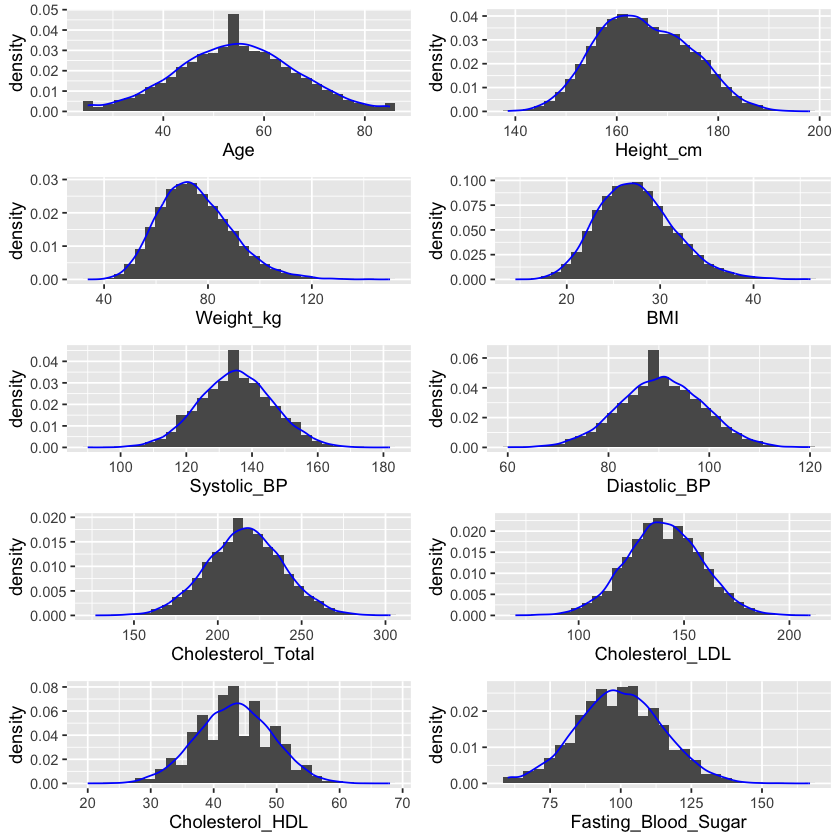

In [33]:
g1<-ggplot(health,aes(x=Age))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue") 

g2<-ggplot(health,aes(x=Height_cm))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g3<-ggplot(health,aes(x=Weight_kg))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g4<-ggplot(health,aes(x=BMI))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g5<-ggplot(health,aes(x=Systolic_BP))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g6<-ggplot(health,aes(x=Diastolic_BP))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g7<-ggplot(health,aes(x=Cholesterol_Total))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g8<-ggplot(health,aes(x=Cholesterol_LDL))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g9<-ggplot(health,aes(x=Cholesterol_HDL))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g10<-ggplot(health,aes(x=Fasting_Blood_Sugar))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 


grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,ncol=2,nrow=5)

#### Corrélation

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


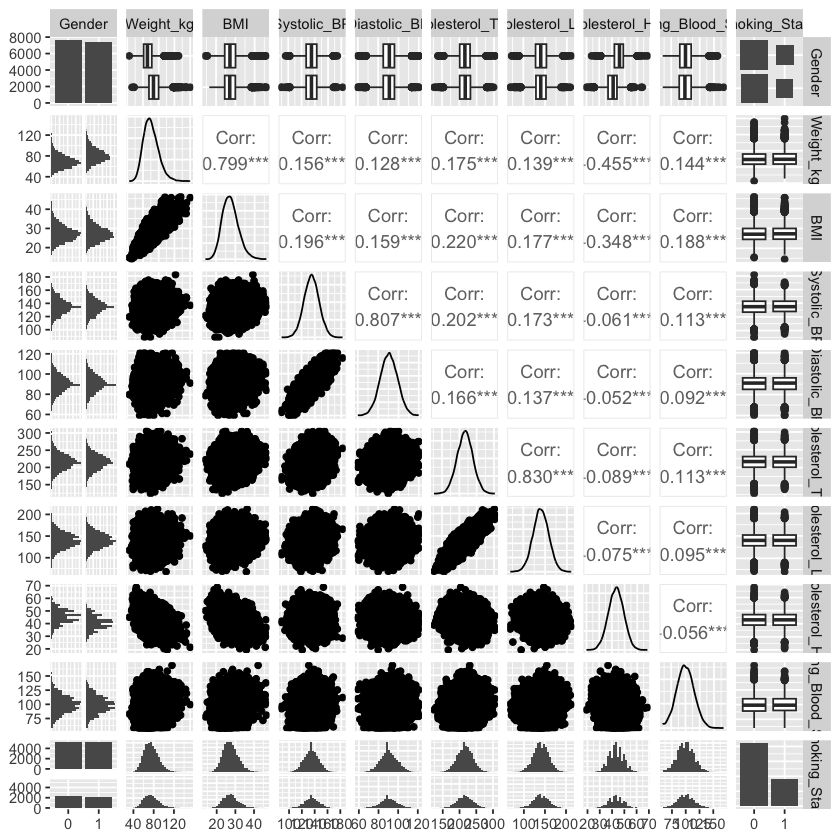

In [34]:
ggpairs(health[, c(2,4:12)])

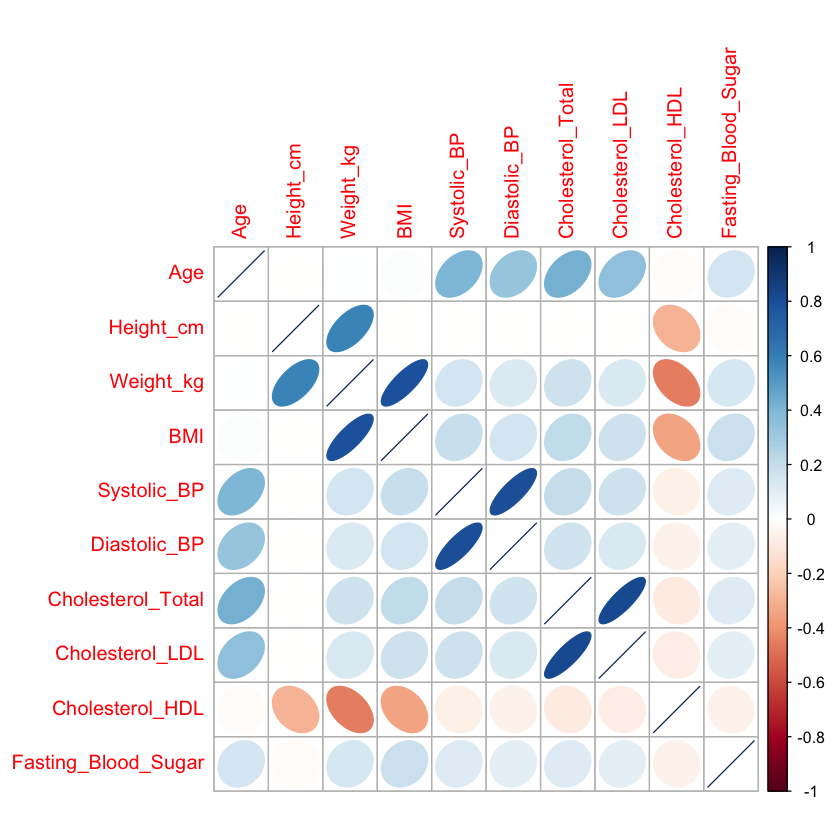

In [35]:
num_cols <- sapply(health, is.numeric)
mat_cor <- cor(health[, num_cols], method = "pearson")  #  pearson, kendall ou spearman

# 2. Visualiser avec ellipses

corrplot(mat_cor, method = "ellipse") 

### Variables Qualitatives

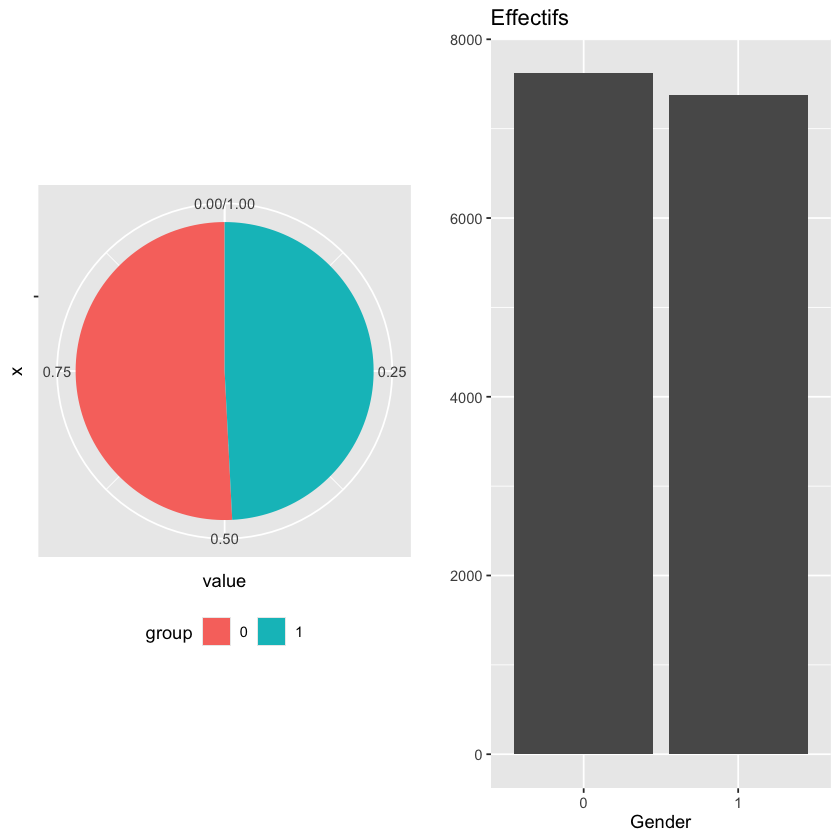

In [36]:

e2<-ggplot(health, aes(x=Gender))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

df2<- data.frame(group = levels(health$Gender),
                 value = as.vector(table(health$Gender))/nrow(health))
g2<-ggplot(df2, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")


grid.arrange(g2,e2,ncol=2)

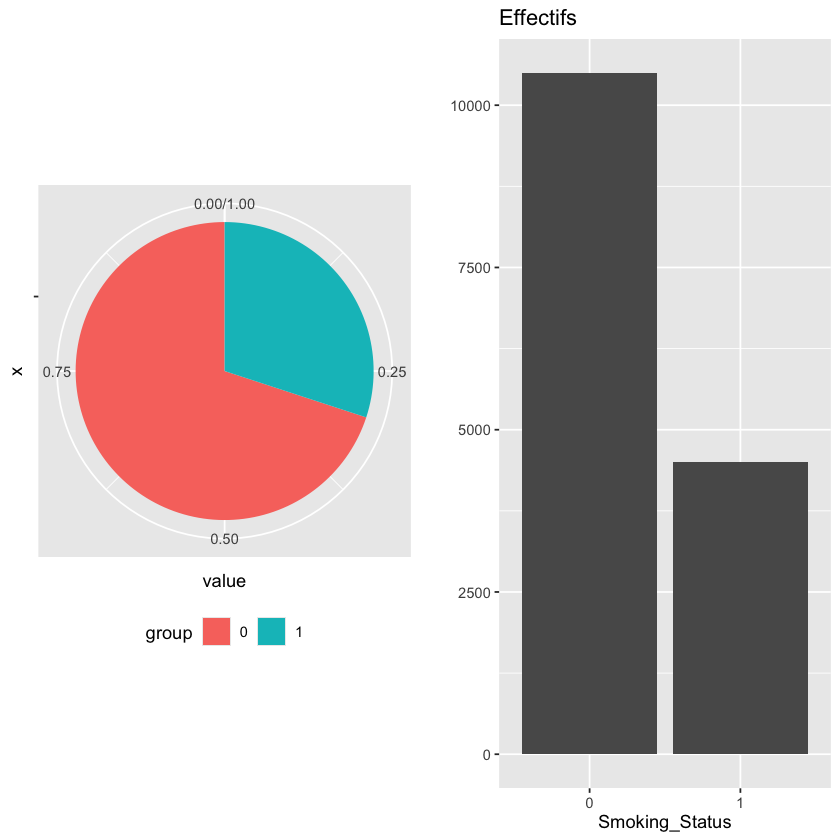

In [37]:
df3<- data.frame(group = levels(health$Smoking_Status),
                 value = as.vector(table(health$Smoking_Status))/nrow(health))
g3<-ggplot(df3, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e3<-ggplot(health, aes(x=Smoking_Status))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g3,e3,ncol=2)

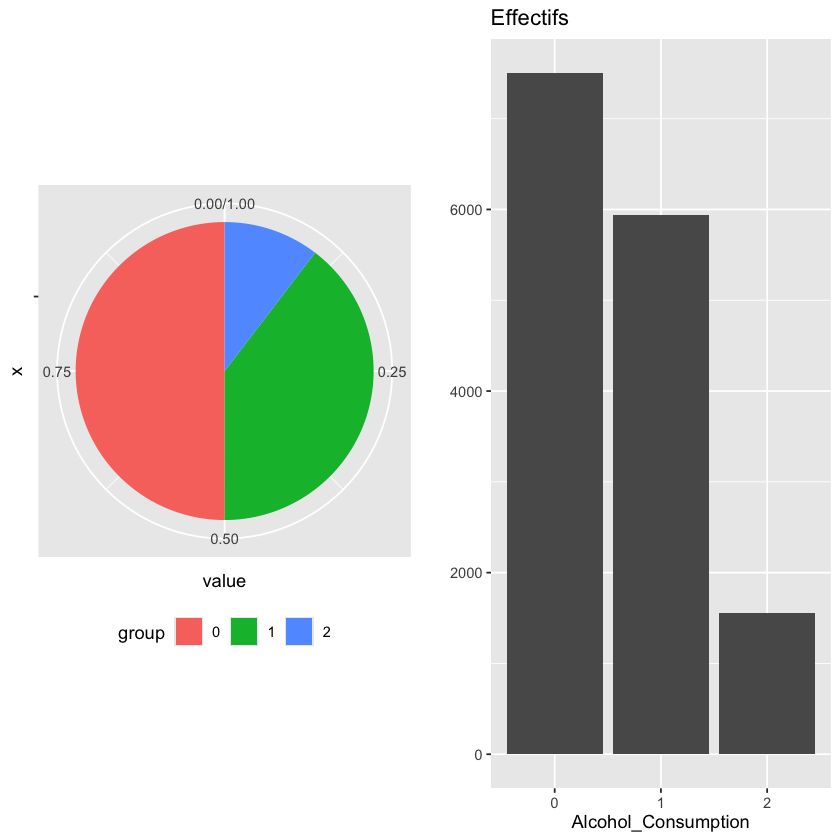

In [38]:
df4<- data.frame(group = levels(health$Alcohol_Consumption),
                 value = as.vector(table(health$Alcohol_Consumption))/nrow(health))
g4<-ggplot(df4, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e4<-ggplot(health, aes(x=Alcohol_Consumption))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g4,e4,ncol=2)

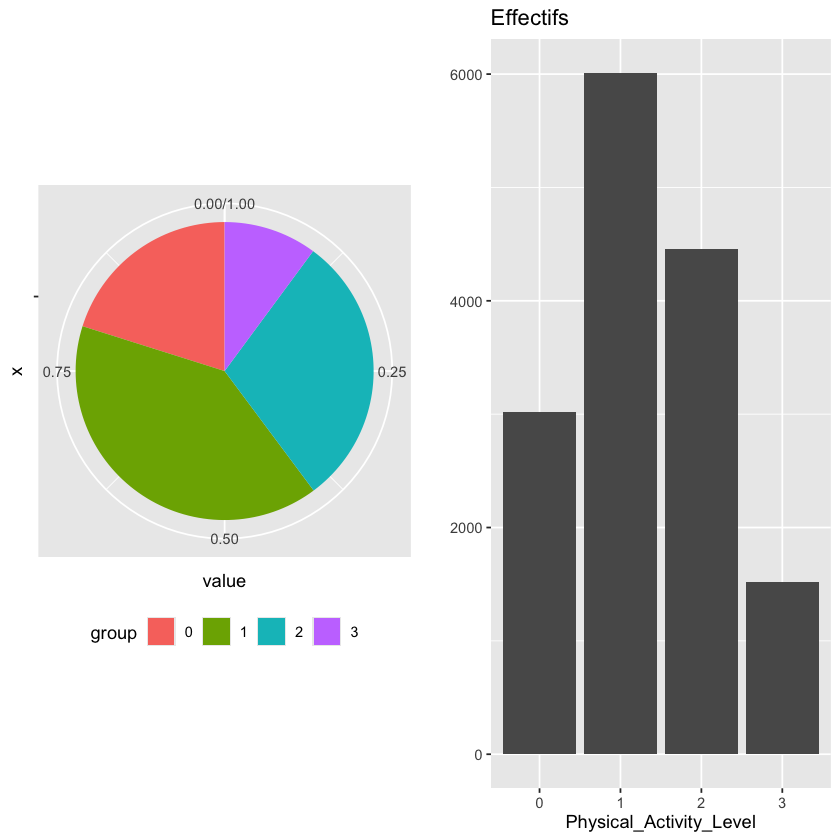

In [39]:
df5<- data.frame(group = levels(health$Physical_Activity_Level),
                 value = as.vector(table(health$Physical_Activity_Level))/nrow(health))
g5<-ggplot(df5, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e5<-ggplot(health, aes(x=Physical_Activity_Level))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g5,e5,ncol=2)

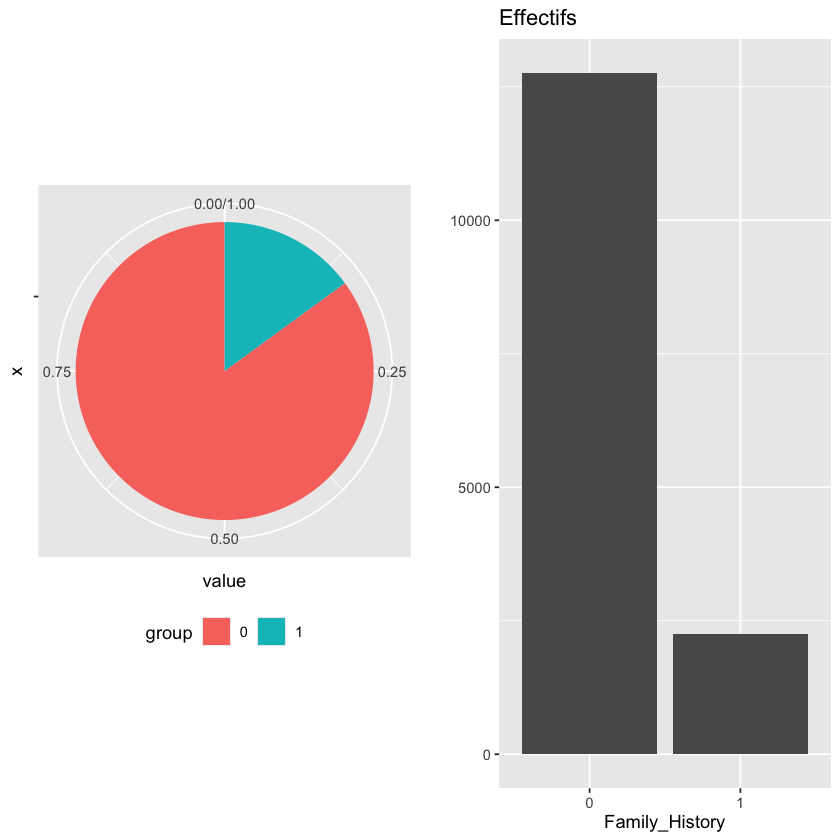

In [40]:
df6<- data.frame(group = levels(health$Family_History),
                 value = as.vector(table(health$Family_History))/nrow(health))
g6<-ggplot(df6, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e6<-ggplot(health, aes(x=Family_History))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g6,e6,ncol=2)

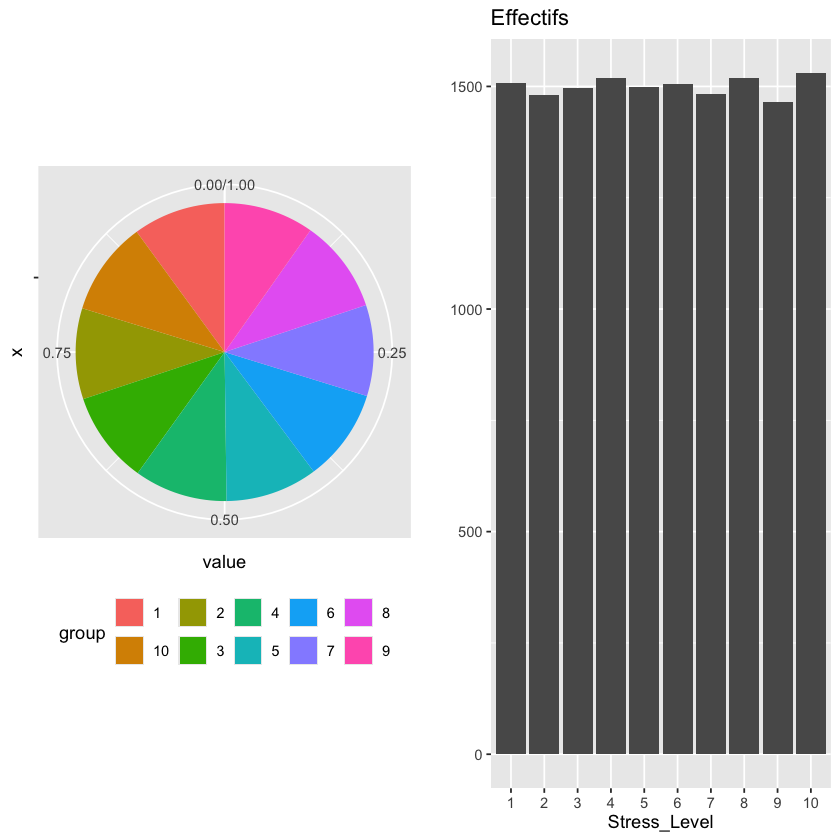

In [41]:
df7<- data.frame(group = levels(health$Stress_Level),
                 value = as.vector(table(health$Stress_Level))/nrow(health))
g7<-ggplot(df7, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e7<-ggplot(health, aes(x=Stress_Level))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g7,e7,ncol=2)

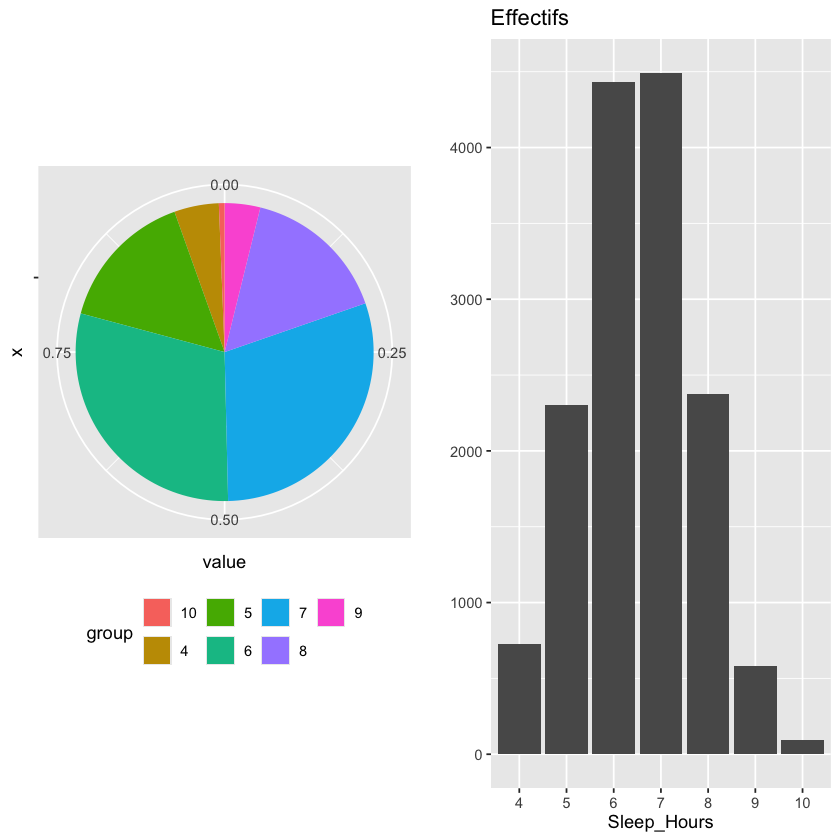

In [42]:
df8<- data.frame(group = levels(health$Sleep_Hours),
                 value = as.vector(table(health$Sleep_Hours))/nrow(health))
g8<-ggplot(df8, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e8<-ggplot(health, aes(x=Sleep_Hours))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g8,e8,ncol=2)

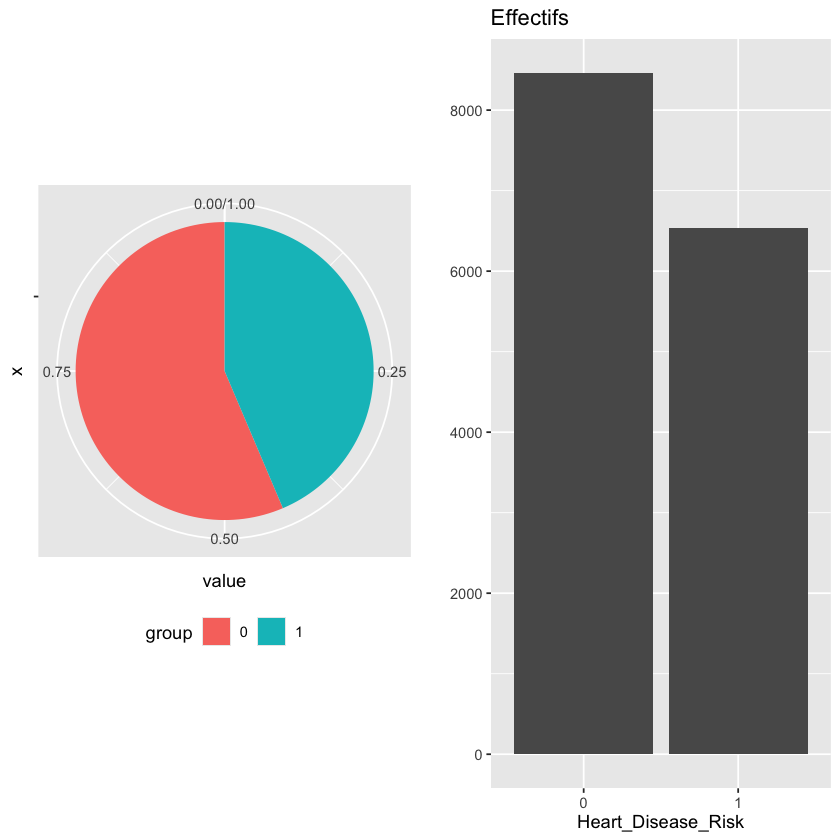

In [43]:
df9<- data.frame(group = levels(health$Heart_Disease_Risk),
                 value = as.vector(table(health$Heart_Disease_Risk))/nrow(health))
g9<-ggplot(df9, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e9<-ggplot(health, aes(x=Heart_Disease_Risk))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g9,e9,ncol=2)

## Construction d'un échantillon test

In [44]:
set.seed(123) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(health) # nombre de lignes dans les données
nvar <- ncol(health) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
test_HDR <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appr_HDR <- setdiff(1:npop, test_HDR) 

Construction des échantillons pour la régression: prévision du risque de maladie cardiaque Heart_Disease_Risk

In [45]:
# construction de l'échantillon d'apprentissage
datappr_HDR <- health[appr_HDR, -11] 
# construction de l'échantillon test
datest_HDR <- health[test_HDR, -11] 
# vérification
str(datappr_HDR)
str(datest_HDR)
#summary(datappr0) 

'data.frame':	12000 obs. of  17 variables:
 $ Age                    : int  53 62 73 52 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  162 175 173 179 160 ...
 $ Weight_kg              : num  76.6 92.4 68.9 79.8 60.3 ...
 $ BMI                    : num  29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  128 141 136 122 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  81 100 96 80 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  203 173 193 236 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  119 124 117 153 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  38 45 45 41 48 46 44 37 38 43 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 1 1 1 2 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 2 1 2 3 2 3 3

'data.frame':	3000 obs. of  17 variables:
 $ Age                    : int  60 60 65 56 43 43 32 65 54 25 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 1 2 1 2 2 1 2 2 ...
 $ Height_cm              : num  156 152 154 161 156 ...
 $ Weight_kg              : num  69 50.4 58.2 70.7 64.7 66.4 65.1 64.8 67.5 60.7 ...
 $ BMI                    : num  28.5 21.7 24.7 27.1 26.6 21.3 24.2 25.9 21.5 24.3 ...
 $ Systolic_BP            : int  132 147 155 142 145 118 125 130 147 135 ...
 $ Diastolic_BP           : int  79 98 101 90 92 84 81 87 95 82 ...
 $ Cholesterol_Total      : int  220 200 231 205 199 182 204 231 218 165 ...
 $ Cholesterol_LDL        : int  134 128 143 123 131 122 134 142 139 113 ...
 $ Cholesterol_HDL        : int  42 51 51 32 50 49 41 54 39 38 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 2 1 1 1 1 1 1 1 1 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 1 1 2 1 2 2 2 1 2 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","

In [46]:
# on normalise l'échantillon d'apprentissage
datappr_nHDR=datappr_HDR
datappr_nHDR[,-c(2,5,11,12,13,14,15,16,17)]=scale(datappr_HDR[,-c(2,5,11,12,13,14,15,16,17)])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr_nHDR=datest_HDR
datestr_nHDR[,-c(2,5,11,12,13,14,15,16,17)]=scale(datest_HDR[,-c(2,5,11,12,13,14,15,16,17)],
                            center=sapply(datappr_HDR[,-c(2,5,11,12,13,14,15,16,17)],mean), # on centre avec les moyennes de l'échantillon d'apprentissage
                            scale=sapply(datappr_HDR[,-c(2,5,11,12,13,14,15,16,17)],sd)) # on réduit avec les écart-types de l'échantillon d'apprentissage
summary(datappr_nHDR)
summary(datestr_nHDR)


      Age           Gender     Height_cm          Weight_kg       
 Min.   :-2.48850   0:6087   Min.   :-2.91289   Min.   :-2.60543  
 1st Qu.:-0.63473   1:5913   1st Qu.:-0.75343   1st Qu.:-0.71330  
 Median : 0.03937            Median :-0.06979   Median :-0.09676  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71347            3rd Qu.: 0.72238   3rd Qu.: 0.61900  
 Max.   : 2.56724            Max.   : 3.55463   Max.   : 4.76469  
                                                                  
      BMI         Systolic_BP         Diastolic_BP      Cholesterol_Total
 Min.   :14.50   Min.   :-4.008428   Min.   :-3.63179   Min.   :-3.7324  
 1st Qu.:24.50   1st Qu.:-0.719534   1st Qu.:-0.65753   1st Qu.:-0.6751  
 Median :27.10   Median :-0.008422   Median : 0.05629   Median :-0.0104  
 Mean   :27.41   Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.:30.00   3rd Qu.: 0.702690   3rd Qu.: 0.65115   3rd Qu.: 0.6542  
 Max.   :46.10   Max

      Age            Gender     Height_cm           Weight_kg       
 Min.   :-2.488498   0:1535   Min.   :-2.912890   Min.   :-2.93851  
 1st Qu.:-0.718989   1:1465   1st Qu.:-0.731731   1st Qu.:-0.68495  
 Median : 0.039372            Median :-0.069787   Median :-0.05424  
 Mean   : 0.002268            Mean   :-0.003441   Mean   : 0.03092  
 3rd Qu.: 0.713470            3rd Qu.: 0.725088   3rd Qu.: 0.63317  
 Max.   : 2.567241            Max.   : 3.522072   Max.   : 5.31037  
                                                                    
      BMI         Systolic_BP         Diastolic_BP       Cholesterol_Total  
 Min.   :15.30   Min.   :-3.563983   Min.   :-3.631793   Min.   :-3.953987  
 1st Qu.:24.77   1st Qu.:-0.630645   1st Qu.:-0.657530   1st Qu.:-0.675051  
 Median :27.30   Median :-0.008422   Median : 0.056293   Median :-0.010402  
 Mean   :27.58   Mean   : 0.010185   Mean   : 0.008586   Mean   : 0.002936  
 3rd Qu.:30.00   3rd Qu.: 0.702690   3rd Qu.: 0.651145   3rd Qu

Construction des échantillons pour la discrimination: prévision de Cholesterol_LDL

In [47]:
#On enlève patient_ID
health <-  health %>% dplyr::select(-Heart_Disease_Risk)

In [48]:
# construction de l'échantillon d'apprentissage
datappr_LDL <- health[appr_HDR,-2]
# construction de l'échantillon test 
datest_LDL <- health[test_HDR,-2] 

# vérification
str(datappr_LDL)
str(datest_LDL)
#summary(datappq)

'data.frame':	12000 obs. of  16 variables:
 $ Age                    : int  53 62 73 52 52 73 64 49 61 49 ...
 $ Height_cm              : num  162 175 173 179 160 ...
 $ Weight_kg              : num  76.6 92.4 68.9 79.8 60.3 ...
 $ BMI                    : num  29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  128 141 136 122 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  81 100 96 80 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  203 173 193 236 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  119 124 117 153 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  38 45 45 41 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  116 90 81 79 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 1 1 1 2 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 2 1 2 3 2 3 3 3 3 1 

In [49]:
# on normalise l'échantillon d'apprentissage
datappr_nLDL=datappr_LDL
datappr_nLDL[,-c(2,5,11,12,13,14,15,16,17)]=scale(datappr_LDL[,-c(2,5,11,12,13,14,15,16,17)])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr_nLDL=datest_LDL
datestr_nLDL[,-c(2,5,11,12,13,14,15,16,17)]=scale(datest_LDL[,-c(2,5,11,12,13,14,15,16,17)],
                            center=sapply(datappr_LDL[,-c(2,5,11,12,13,14,15,16,17)],mean), # on centre avec les moyennes de l'échantillon d'apprentissage
                            scale=sapply(datappr_LDL[,-c(2,5,11,12,13,14,15,16,17)],sd)) # on réduit avec les écart-types de l'échantillon d'apprentissage
summary(datappr_nLDL)
summary(datestr_nLDL)


      Age             Height_cm       Weight_kg             BMI          
 Min.   :-2.48850   Min.   :138.5   Min.   :-2.60543   Min.   :-3.12459  
 1st Qu.:-0.63473   1st Qu.:158.4   1st Qu.:-0.71330   1st Qu.:-0.70467  
 Median : 0.03937   Median :164.7   Median :-0.09676   Median :-0.07549  
 Mean   : 0.00000   Mean   :165.3   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71347   3rd Qu.:172.0   3rd Qu.: 0.61900   3rd Qu.: 0.62628  
 Max.   : 2.56724   Max.   :198.1   Max.   : 4.76469   Max.   : 4.52235  
                                                                         
  Systolic_BP     Diastolic_BP      Cholesterol_Total Cholesterol_LDL   
 Min.   : 90.0   Min.   :-3.63179   Min.   :-3.7324   Min.   :-3.92689  
 1st Qu.:127.0   1st Qu.:-0.65753   1st Qu.:-0.6751   1st Qu.:-0.69028  
 Median :135.0   Median : 0.05629   Median :-0.0104   Median :-0.02064  
 Mean   :135.1   Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.:143.0   3rd Qu.: 0.65115   3rd Qu.

      Age              Height_cm       Weight_kg             BMI          
 Min.   :-2.488498   Min.   :138.5   Min.   :-2.93851   Min.   :-2.93099  
 1st Qu.:-0.718989   1st Qu.:158.6   1st Qu.:-0.68495   1st Qu.:-0.63812  
 Median : 0.039372   Median :164.7   Median :-0.05424   Median :-0.02710  
 Mean   : 0.002268   Mean   :165.3   Mean   : 0.03092   Mean   : 0.04128  
 3rd Qu.: 0.713470   3rd Qu.:172.0   3rd Qu.: 0.63317   3rd Qu.: 0.62628  
 Max.   : 2.567241   Max.   :197.8   Max.   : 5.31037   Max.   : 4.40135  
                                                                          
  Systolic_BP     Diastolic_BP       Cholesterol_Total   Cholesterol_LDL    
 Min.   : 95.0   Min.   :-3.631793   Min.   :-3.953987   Min.   :-3.871085  
 1st Qu.:128.0   1st Qu.:-0.657530   1st Qu.:-0.675051   1st Qu.:-0.634481  
 Median :135.0   Median : 0.056293   Median :-0.010402   Median :-0.020643  
 Mean   :135.2   Mean   : 0.008586   Mean   : 0.002936   Mean   :-0.004088  
 3rd Qu.:143.0 

Graphe des résidus

In [50]:
gplot.res <- function(x, y, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(-5, 5)+ylim(-5, 5)+
    ylab("Résidus")+ xlab("Valeurs prédites")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

# Prévision par modèle linéaire gaussien

## Modèle linéaire

### Sans sélection de variables

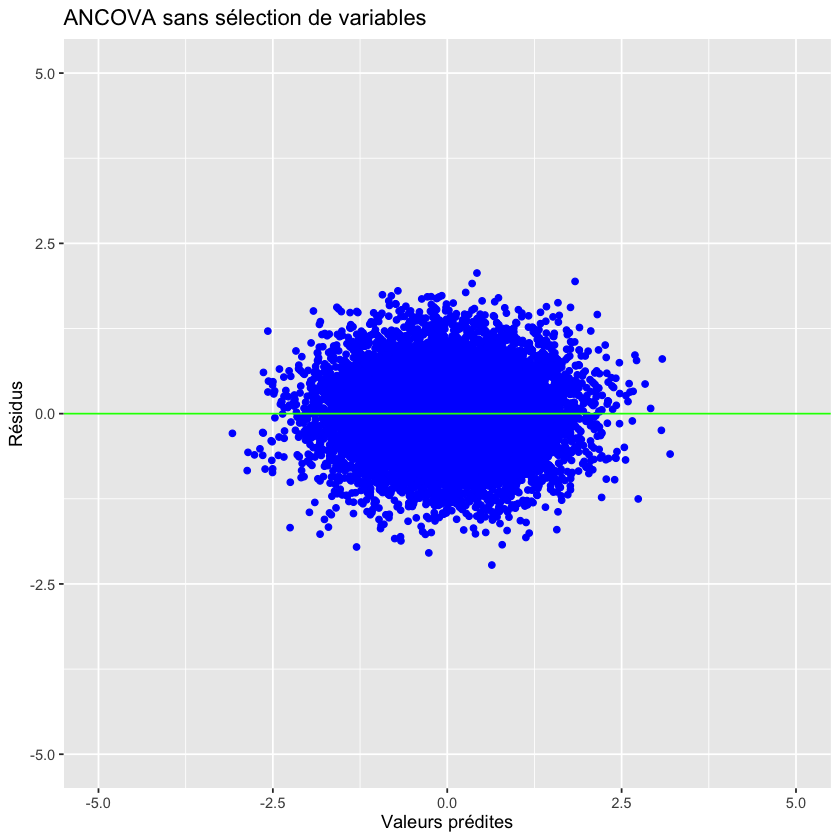

In [51]:
# estimation du modèle sans interaction
reg.lm <-aov(Cholesterol_LDL ~ . , data = datappr_nLDL)
# Extraction des résidus et des valeurs ajustées de ce modèle
res.lm <- reg.lm$residuals
fit.lm <- reg.lm$fitted.values
# Graphe des résidus. 
gplot.res(fit.lm,res.lm,"ANCOVA sans sélection de variables")

Heart_Disease_Risk étant une variable qualitative binaire, on va utiliser un modèle logit.

## [Prévision par modèle binomial](http://wikistat.fr/pdf/st-m-app-rlogit.pdf)

### Régression logistique sans interaction

In [52]:
# estimation du modèle complet
log.lm <- glm(Heart_Disease_Risk ~. , data = datappr_nHDR, family = binomial)
# significativité des paramètres
anova(log.lm, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16447.54,NA
Age,1,3.258555e+02,11998,16121.69,7.682328e-73
Gender,1,2.863548e-01,11997,16121.40,5.925660e-01
Height_cm,1,1.325186e+00,11996,16120.07,2.496635e-01
Weight_kg,1,2.207439e+02,11995,15899.33,6.224608e-50
BMI,1,4.263602e+00,11994,15895.07,3.893727e-02
Systolic_BP,1,1.850425e+02,11993,15710.02,3.841669e-42
Diastolic_BP,1,3.787130e-04,11992,15710.02,9.844737e-01
Cholesterol_Total,1,1.981823e+01,11991,15690.21,8.516634e-06


In [53]:
# Recherche d'un modèle optimal au sens d'Akaïke
log.lm.step <- step(log.lm, direction = "backward")

Start:  AIC=12890.26
Heart_Disease_Risk ~ Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Smoking_Status + Alcohol_Consumption + 
    Physical_Activity_Level + Family_History + Stress_Level + 
    Sleep_Hours

                          Df Deviance   AIC
- Alcohol_Consumption      2    12826 12888
- Diastolic_BP             1    12824 12888
- Height_cm                1    12824 12888
- Weight_kg                1    12824 12888
- Gender                   1    12825 12889
- BMI                      1    12826 12890
- Cholesterol_HDL          1    12826 12890
- Cholesterol_Total        1    12826 12890
<none>                          12824 12890
- Sleep_Hours              6    12849 12903
- Cholesterol_LDL          1    12853 12917
- Systolic_BP              1    12914 12978
- Age                      1    12921 12985
- Stress_Level             9    13006 13054
- Physical_Activity_Level  3    13242 

In [54]:
# Modèle obtenu
anova(log.lm.step, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16447.54,NA
Age,1,325.85545,11998,16121.69,7.682328e-73
BMI,1,224.66038,11997,15897.03,8.707308e-51
Systolic_BP,1,185.42245,11996,15711.60,3.173758e-42
Cholesterol_LDL,1,40.67575,11995,15670.93,1.797035e-10
Smoking_Status,1,1602.32052,11994,14068.61,0.000000e+00
Physical_Activity_Level,3,391.36206,11991,13677.24,1.644914e-84
Family_History,1,639.78466,11990,13037.46,3.721969e-141
Stress_Level,9,182.76625,11981,12854.69,1.339581e-34


In [55]:
# matrice de confusion de l'échantillon d'apprentissage et erreur apparente
table(log.lm.step$fitted.values > 0.5, datappr_nHDR[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 5437 1874
  TRUE  1313 3376

### Régression logistique avec interactions

In [56]:
# régression avec le modèle minimum
log.qm <- glm(Heart_Disease_Risk ~ 1, data = datappr_nHDR,family = binomial)
# algorithme stepwise en précisant le plus grand 
# modèle possible
log.qm.step1 <- step(log.qm, direction = "both",
    scope = list(lower = ~1, upper = ~ (Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Smoking_Status + Alcohol_Consumption + 
    Physical_Activity_Level + Family_History + Stress_Level + 
    Sleep_Hours)^2), 
    family=binomial)

Start:  AIC=16449.54
Heart_Disease_Risk ~ 1

                          Df Deviance   AIC
+ Smoking_Status           1    14930 14934
+ Systolic_BP              1    15951 15955
+ Family_History           1    15968 15972
+ Age                      1    16122 16126
+ Diastolic_BP             1    16122 16126
+ Physical_Activity_Level  3    16140 16148
+ BMI                      1    16226 16230
+ Cholesterol_LDL          1    16232 16236
+ Cholesterol_Total        1    16238 16242
+ Weight_kg                1    16290 16294
+ Stress_Level             9    16298 16318
+ Cholesterol_HDL          1    16406 16410
+ Sleep_Hours              6    16424 16438
<none>                          16448 16450
+ Height_cm                1    16446 16450
+ Gender                   1    16447 16451
+ Alcohol_Consumption      2    16447 16453

Step:  AIC=14934.37
Heart_Disease_Risk ~ Smoking_Status

                          Df Deviance   AIC
+ Family_History           1    14375 14381
+ Systolic_BP    

In [57]:
anova(log.qm.step1, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16447.54,NA
Smoking_Status,1,1517.173800,11998,14930.37,0.000000e+00
Family_History,1,555.174671,11997,14375.19,9.425372e-123
Systolic_BP,1,575.227733,11996,13799.96,4.094051e-127
Physical_Activity_Level,3,399.825834,11993,13400.14,2.414799e-86
Stress_Level,9,180.969728,11984,13219.17,3.178560e-34
Cholesterol_LDL,1,161.854929,11983,13057.31,4.450233e-37
BMI,1,106.144474,11982,12951.17,6.855075e-25
Age,1,96.476353,11981,12854.69,9.031612e-23


### Prévision de l'échantillon test

In [58]:
# Prévision du modèle quadratique
pred.log <- predict(log.qm.step1, newdata = datestr_nHDR, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(pred.log > 0.5, datestr_nHDR[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 1380  482
  TRUE   330  808

### Regression logistique LASSO

In [59]:
# Installation du package si nécessaire
# install.packages("glmnet")``
library(glmnet)

In [60]:
# Préparation de la matrice de design avec toutes les interactions d'ordre 2
X <- model.matrix(Heart_Disease_Risk ~ (Age + Gender + Height_cm + Weight_kg + BMI + 
                    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
                    Cholesterol_HDL + Smoking_Status + Alcohol_Consumption + 
                    Physical_Activity_Level + Family_History + Stress_Level + 
                    Sleep_Hours)^2, 
                  data = datappr_nHDR)[, -1]  # on retire l'intercept

y <- datappr_nHDR$Heart_Disease_Risk

# Régression logistique avec pénalité L1 (LASSO) via cross-validation
set.seed(42)
log.qm.lasso.cv <- cv.glmnet(X, y, 
                               family = "binomial", 
                               alpha = 1,           # alpha = 1 => L1 pure
                               nfolds = 10,
                               type.measure = "deviance")

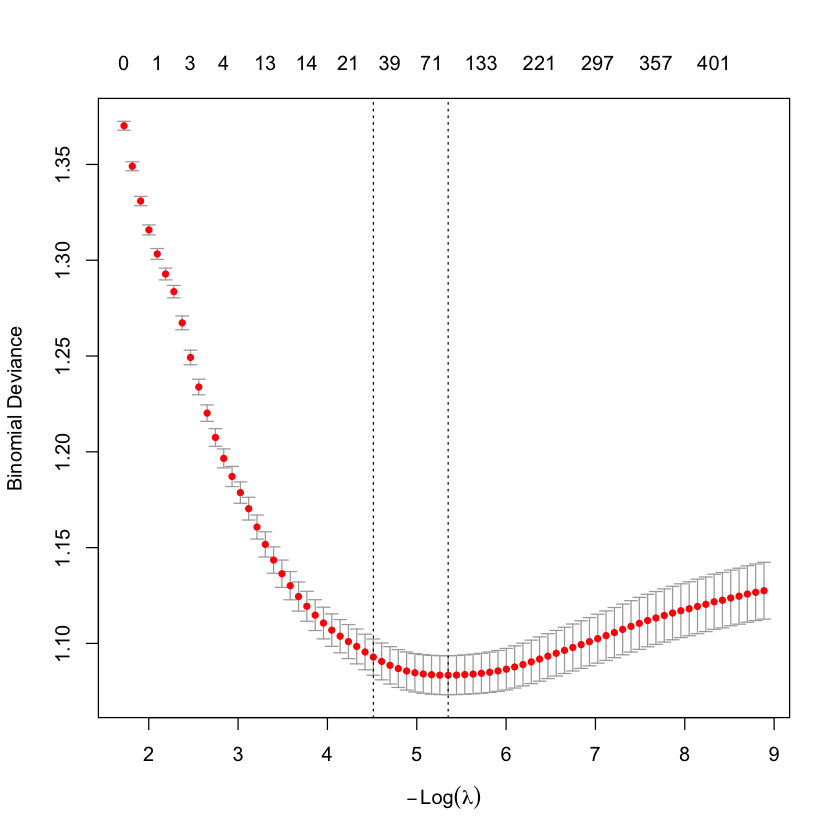

In [61]:
# Visualisation de la cross-validation
plot(log.qm.lasso.cv)


In [62]:
# Lambda optimal
lambda.min <- log.qm.lasso.cv$lambda.min  # erreur minimale
lambda.1se <- log.qm.lasso.cv$lambda.1se  # modèle plus parcimonieux

cat("Lambda min :", lambda.min, "\n")
cat("Lambda 1se :", lambda.1se, "\n")

# Coefficients retenus avec lambda.1se
coef(log.qm.lasso.cv, s = "lambda.1se")

# Nombre de variables retenues
coefs <- coef(log.qm.lasso.cv, s = "lambda.1se")
cat("Nombre de coefficients non nuls :", sum(coefs != 0), "\n")

Lambda min : 0.004741806 
Lambda 1se : 0.01095419 


474 x 1 sparse Matrix of class "dgCMatrix"
                                                 lambda.1se
(Intercept)                                   -1.6863621960
Age                                            0.1473221481
Gender1                                        .           
Height_cm                                      .           
Weight_kg                                      .           
BMI                                            0.0338155536
Systolic_BP                                    0.2918541336
Diastolic_BP                                   .           
Cholesterol_Total                              .           
Cholesterol_LDL                                0.0660749116
Cholesterol_HDL                                .           
Smoking_Status1                                1.2211505657
Alcohol_Consumption1                           .           
Alcohol_Consumption2                           .           
Physical_Activity_Level1                      -0.07183561

Nombre de coefficients non nuls : 30 


In [63]:
# Prédictions (probabilités)
pred.proba <- predict(log.qm.lasso.cv, 
                      newx = X, 
                      s = "lambda.1se", 
                      type = "response")

# Classes prédites (seuil 0.5)
pred.class <- ifelse(pred.proba > 0.5, 1, 0)

# Matrice de confusion
table(Prédit = pred.class, Observé = y)

      Observé
Prédit    0    1
     0 5536 2015
     1 1214 3235

### Courbes ROC

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



AUC Logistique complet : 0.797 
AUC Stepwise           : 0.797 
AUC LASSO              : 0.791 


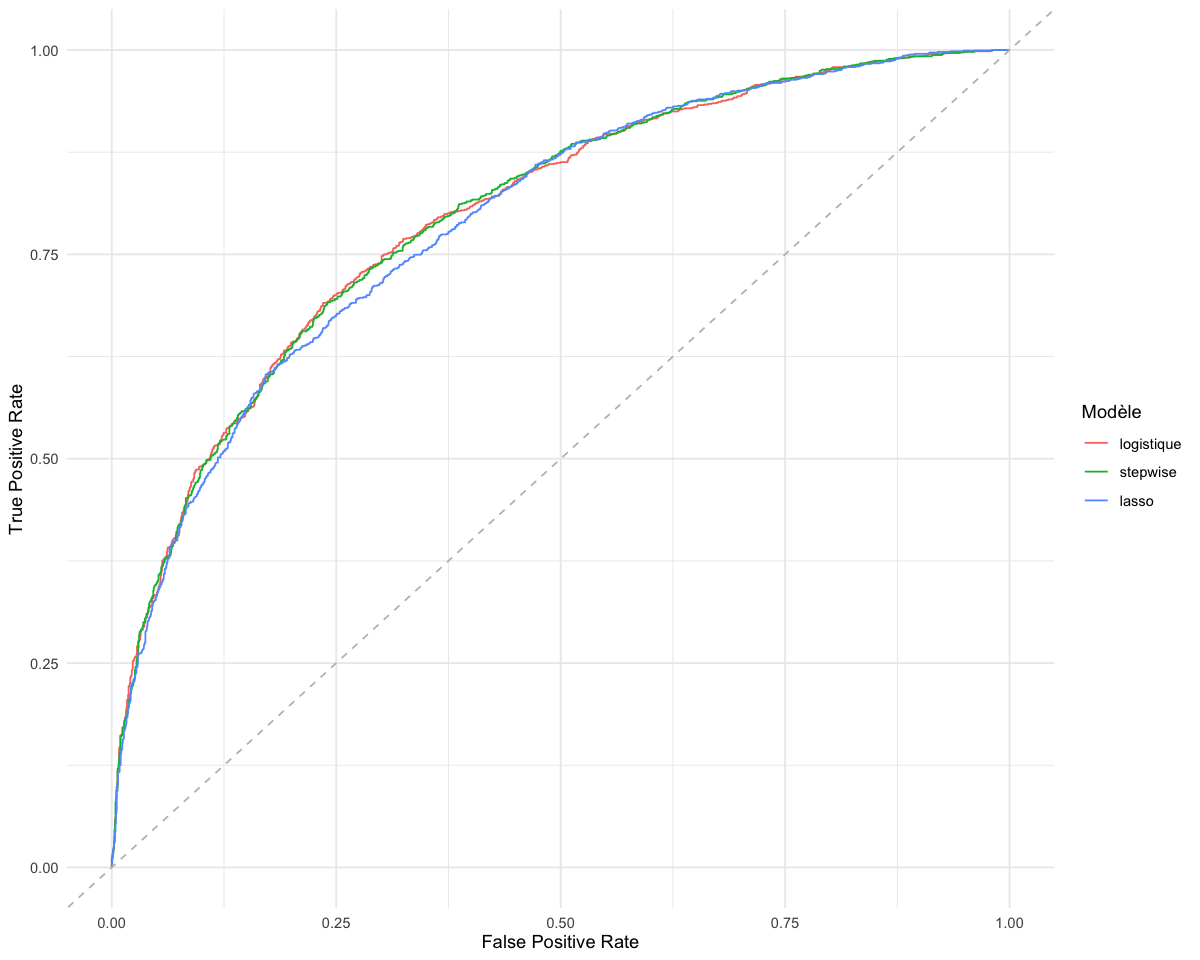

In [80]:
library(pROC)
library(ggplot2)

# ── 1. Modèle logistique complet (log.lm) ──────────────────────────────────
rocobjglm <- roc(datestr_nHDR$Heart_Disease_Risk,
                 predict(log.lm, newdata = datestr_nHDR, type = "response"))

# ── 2. Modèle stepwise (log.qm.step1) ─────────────────────────────────────
rocobjstep <- roc(datestr_nHDR$Heart_Disease_Risk,
                  predict(log.qm.step1, newdata = datestr_nHDR, type = "response"))

# ── 3. Modèle LASSO (log.qm.lasso.cv) ─────────────────────────────────────
X_test <- model.matrix(Heart_Disease_Risk ~ (Age + Gender + Height_cm + Weight_kg + BMI + 
                    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
                    Cholesterol_HDL + Smoking_Status + Alcohol_Consumption + 
                    Physical_Activity_Level + Family_History + Stress_Level + 
                    Sleep_Hours)^2, 
                  data = datestr_nHDR)[, -1]

roclasso <- as.vector(predict(log.qm.lasso.cv, newx = X_test, 
                               s = "lambda.1se", type = "response"))

rocobjlasso <- roc(datestr_nHDR$Heart_Disease_Risk, roclasso)

# ── AUC ────────────────────────────────────────────────────────────────────
cat("AUC Logistique complet :", round(auc(rocobjglm),  3), "\n")
cat("AUC Stepwise           :", round(auc(rocobjstep), 3), "\n")
cat("AUC LASSO              :", round(auc(rocobjlasso),3), "\n")

# ── Plot ───────────────────────────────────────────────────────────────────
options(repr.plot.width = 10, repr.plot.height = 8)
ggroc(list(logistique = rocobjglm,
           stepwise   = rocobjstep,
           lasso      = rocobjlasso),
      legacy.axes = TRUE) +
  xlab("False Positive Rate") +
  ylab("True Positive Rate") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey") +
  labs(color = "Modèle") +
  theme_minimal()

# [Analyse discriminante](http://wikistat.fr/pdf/st-m-app-add.pdf)

In [64]:
# analyse discriminante linéaire
disc.lda=lda(Heart_Disease_Risk~.,data=datappr_nHDR) 
# analyse discriminante quadratique 
disc.qda=qda(Heart_Disease_Risk~.,data=datappr_nHDR) 
# k plus proches voisins
disc.knn=knn(datappr_nHDR[,c(-17)],datappr_nHDR[,c(-17)],datappr_nHDR$Heart_Disease_Risk,k=10) 

In [65]:
library(caret)
lda.fit<-train(Heart_Disease_Risk~.,data=datappr_nHDR,method="lda")
qda.fit<-train(Heart_Disease_Risk~.,data=datappr_nHDR,method="qda")
knn.fit<-train(Heart_Disease_Risk~.,data=datappr_nHDR,method="knn")

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




### Estimation de l'erreur de prévision par validation croisée

#### Sans utiliser la librairie `caret`

In [66]:
# erreur par validation croisée  en analyse discriminante linéaire
disc.lda=lda(Heart_Disease_Risk~.,data=datappr_nHDR,CV=T) 
# estimer le taux d'erreur à partir de la matrice de confusion
t1=table(data=datappr_nHDR[,"Heart_Disease_Risk"],disc.lda$class)  
t1

# Faux négatifs : pour chaque ligne, tout ce qui n'est pas sur la diagonale
FN <- rowSums(t1) - diag(t1)

# Faux positifs : pour chaque colonne, tout ce qui n'est pas sur la diagonale
FP <- colSums(t1) - diag(t1)

# Total sur toutes les classes
total_FN <- sum(FN)
total_FP <- sum(FP)

m1=(total_FN+total_FP)/sum(t1)*100
m1

    
data    0    1
   0 5472 1278
   1 1944 3306

[1] 53.7

In [67]:
cat("Erreur CV — LDA:", round(m1, 1), "%\n")

Erreur CV — LDA: 53.7 %


In [68]:
# analyse discriminante quadratique
disc.qda=qda(Heart_Disease_Risk~.,data=datappr_nHDR,CV=T)  
t2=table(datappr_nHDR[,"Heart_Disease_Risk"],disc.qda$class)
t2
# Faux négatifs : pour chaque ligne, tout ce qui n'est pas sur la diagonale
FN <- rowSums(t2) - diag(t2)

# Faux positifs : pour chaque colonne, tout ce qui n'est pas sur la diagonale
FP <- colSums(t2) - diag(t2)

# Total sur toutes les classes
total_FN <- sum(t2) - sum(diag(t2))   # tout sauf les bons
total_FP <- sum(t2) - sum(diag(t2))   # même chose si on prend toutes les classes

m1=(total_FN+total_FP)/sum(t2)*100
m1

   
       0    1
  0 4765 1985
  1 1698 3552

[1] 61.38333

In [69]:
cat("Erreur CV — LDA:", round(m1, 1), "%\n")

Erreur CV — LDA: 61.4 %



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element




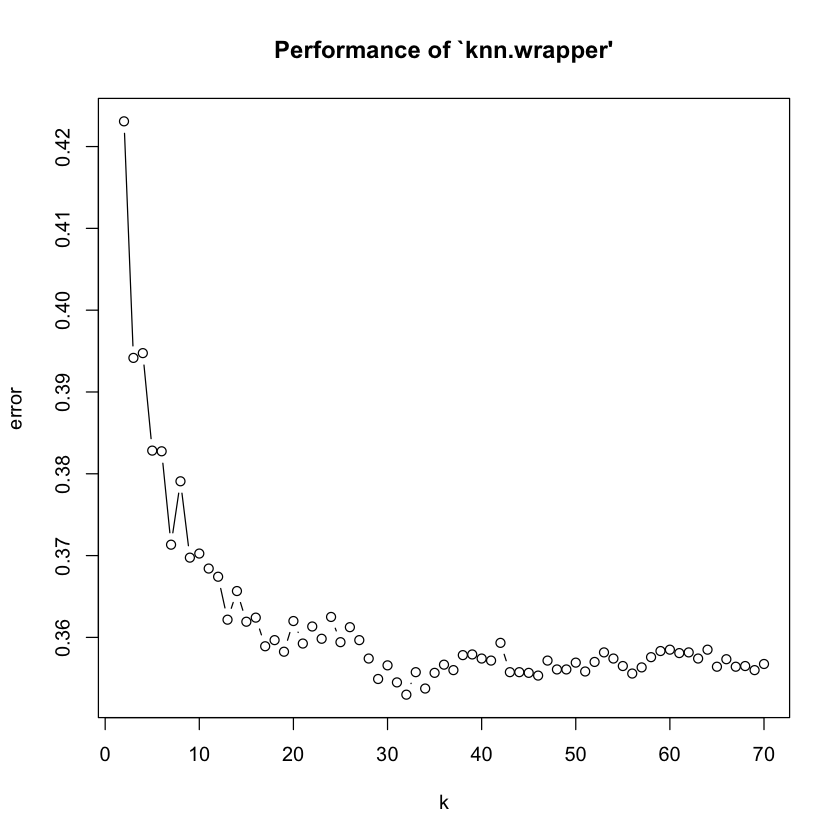

In [70]:
# k plus proches voisins: optimisation de k
library(e1071)
plot(tune.knn(as.matrix(datappr_nHDR[,c(-17)]),as.factor(datappr_nHDR[,17]),k=2:70))

#### Avec la librairie `caret`

In [71]:
# Validation croisée avec 10 folds
param_train<-trainControl(method="cv",number=38)
# erreur par validation croisée  en analyse discriminante linéaire
lda.fit <- train(Heart_Disease_Risk~.,data=datappr_nHDR,method="lda",trControl=param_train)
# estimer le taux d'erreur à partir de la matrice de confusion
table(datappr_nHDR[,"Heart_Disease_Risk"],predict(lda.fit,datappr_nHDR[,c(-17)])) 

   
       0    1
  0 5482 1268
  1 1931 3319

In [72]:
# erreur par validation croisée  en analyse discriminante quadratique
qda.fit <- train(Heart_Disease_Risk~.,data=datappr_nHDR,method="qda",trControl=param_train)
# estimer le taux d'erreur à partir de la matrice de confusion
table(datappr_nHDR[,"Heart_Disease_Risk"],predict(qda.fit,datappr_nHDR[,c(-17)])) 

   
       0    1
  0 4837 1913
  1 1624 3626

In [73]:
# erreur par validation croisée  en kNN
knn.fit <- train(Heart_Disease_Risk~.,data=datappr_nHDR,method="knn",trControl=param_train,tuneLength=20)
# estimer le taux d'erreur à partir de la matrice de confusion
table(datappr_nHDR[,"Heart_Disease_Risk"],predict(knn.fit,datappr_nHDR[,c(-17)])) 

   
       0    1
  0 5726 1024
  1 2632 2618

### Prévision de l'échantillon test

#### Matrices de confusion

In [74]:
## méthode LDA
table(predict(lda.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])
sum(predict(lda.fit,datestr_nHDR)!=datestr_nHDR[,"Heart_Disease_Risk"])/nrow(datestr_nHDR)

   
       0    1
  0 1394  495
  1  316  795

[1] 0.2703333

In [75]:
## méthode QDA
table(predict(qda.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])
sum(predict(qda.fit,datestr_nHDR)!=datestr_nHDR[,"Heart_Disease_Risk"])/nrow(datestr_nHDR)

   
       0    1
  0 1229  460
  1  481  830

[1] 0.3136667

In [76]:
## méthode KNN
table(predict(knn.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])
sum(predict(knn.fit,datestr_nHDR)!=datestr_nHDR[,"Heart_Disease_Risk"])/nrow(datestr_nHDR)

   
       0    1
  0 1386  739
  1  324  551

[1] 0.354

In [77]:
confusionMatrix(predict(knn.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1386  739
         1  324  551
                                          
               Accuracy : 0.6457          
                 95% CI : (0.6282, 0.6628)
    No Information Rate : 0.57            
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.2474          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.8105          
            Specificity : 0.4271          
         Pos Pred Value : 0.6522          
         Neg Pred Value : 0.6297          
             Prevalence : 0.5700          
         Detection Rate : 0.4620          
   Detection Prevalence : 0.7083          
      Balanced Accuracy : 0.6188          
                                          
       'Positive' Class : 0               
                        

#### Courbes ROC

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



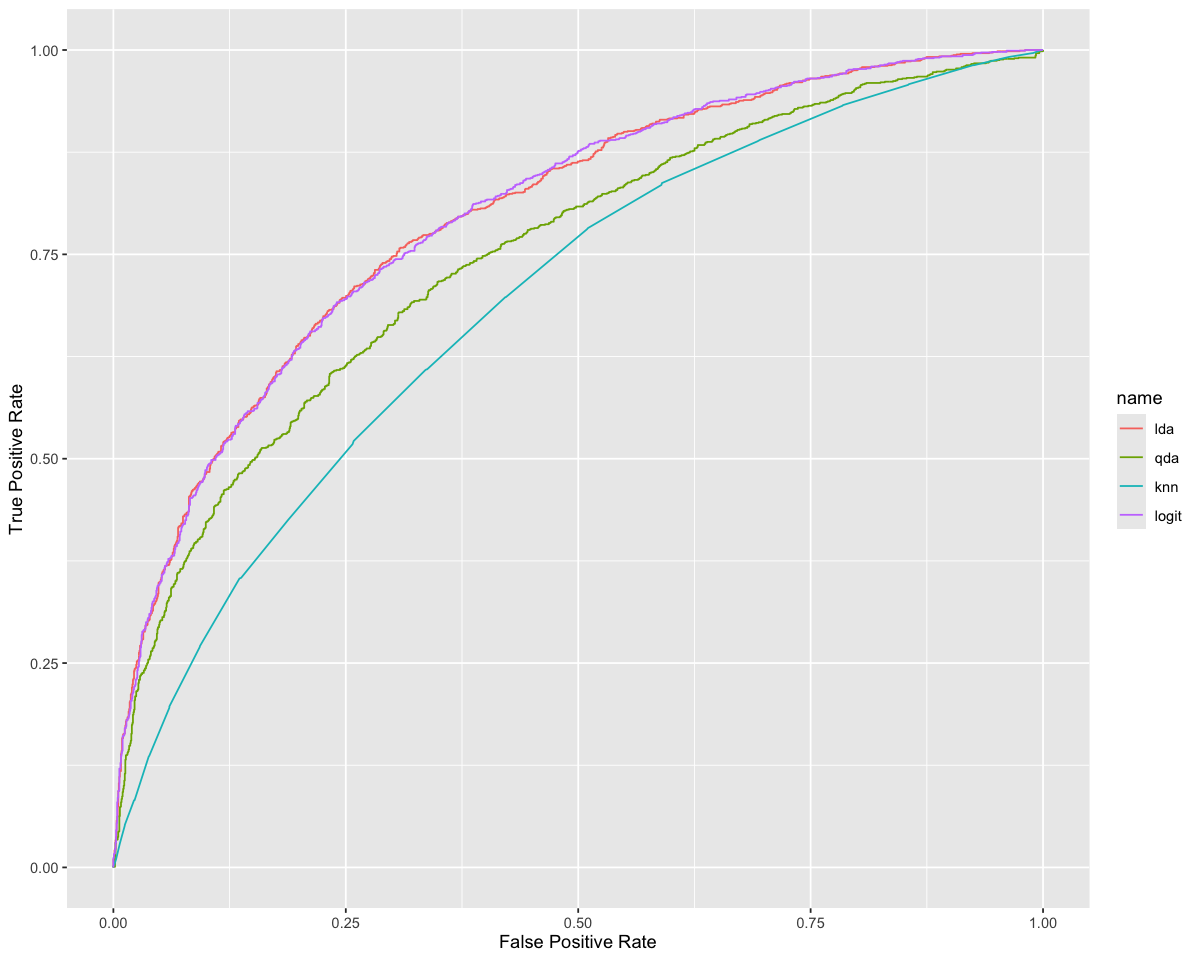

In [78]:
rocobjlda<-roc(datestr_nHDR$Heart_Disease_Risk,predict(lda.fit,datestr_nHDR,type="prob")[,2])
rocobjqda<-roc(datestr_nHDR$Heart_Disease_Risk,predict(qda.fit,datestr_nHDR,type="prob")[,2])
rocobjknn<-roc(datestr_nHDR$Heart_Disease_Risk,predict(knn.fit,datestr_nHDR,type="prob")[,2])
rocobjlogit<-roc(datestr_nHDR[, "Heart_Disease_Risk"],predict(log.qm.step1, newdata = datestr_nHDR, type="response"))

options(repr.plot.width = 10, repr.plot.height = 8)
ggroc(list(lda=rocobjlda,qda=rocobjqda,knn=rocobjknn,logit=rocobjlogit),legacy.axes=T)+
  xlab("False Positive Rate")+
  ylab("True Positive Rate")

# [Séparateur à Vaste Marge (SVM)](http://wikistat.fr/pdf/st-m-app-svm.pdf)


## Régression


In [81]:
library(e1071)
help(svm)

svm                   package:e1071                    R Documentation

_S_u_p_p_o_r_t _V_e_c_t_o_r _M_a_c_h_i_n_e_s

_D_e_s_c_r_i_p_t_i_o_n:

     ‘svm’ is used to train a support vector machine. It can be used to
     carry out general regression and classification (of nu and
     epsilon-type), as well as density-estimation. A formula interface
     is provided.

_U_s_a_g_e:

     ## S3 method for class 'formula'
     svm(formula, data = NULL, ..., subset, na.action =
     na.omit, scale = TRUE)
     ## Default S3 method:
     svm(x, y = NULL, scale = TRUE, type = NULL, kernel =
     "radial", degree = 3, gamma = if (is.vector(x)) 1 else 1 / ncol(x),
     coef0 = 0, cost = 1, nu = 0.5,
     class.weights = NULL, cachesize = 40, tolerance = 0.001, epsilon = 0.1,
     shrinking = TRUE, cross = 0, probability = FALSE, fitted = TRUE,
     ..., subset, na.action = na.omit)
     
_A_r_g_u_m_e_n_t_s:

 formula: a symbolic description of the mod

In [82]:
svm.reg_HDR = svm( Heart_Disease_Risk ~. , data = datappr_nHDR)
summary(svm.reg_HDR)


Call:
svm(formula = Heart_Disease_Risk ~ ., data = datappr_nHDR)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  7555

 ( 3814 3741 )


Number of Classes:  2 

Levels: 
 0 1




### Extraction des paramètres optimaux

In [86]:
#set.seed(2021)
svm.reg.tune_HDR = tune.svm(Heart_Disease_Risk ~. , data = datappr_nHDR,scale = TRUE, cost = c(1, 2, 3),gamma = c(0.02, 0.05, 0.1))
plot(svm.reg.tune_HDR)

In [84]:
svm.reg.tune_HDR$best.parameters$cost
svm.reg.tune_HDR$best.parameters$gamma

ERROR: Error: object 'svm.reg.tune_HDR' not found


### Regression Optimale

In [ ]:
svm.reg_HDR = svm(Heart_Disease_Risk ~. , data = datappr_nHDR, cost = svm.reg.tune_HDR$best.parameters$cost, 
    gamma = svm.reg.tune_HDR$best.parameters$gamma, epsilon=0.1)
summary(svm.reg_HDR)

### Graphes de résidus

In [ ]:
# calcul et graphe des résidus
fit.svmr_HDR=fit.svmr=svm.reg_HDR$fitted
res.svmr_HDR=fit.svmr_HDR-datappr_nHDR[,"Heart_Disease_Risk"]
gplot.res(fit.svmr_HDR,res.svmr_HDR,titre="Graphe des Résidus")

### Discrimination

In [ ]:
# optimisation
svm.dis.tune_HDR = tune.svm(Heart_Disease_Risk ~. , data = datappr_nHDR, cost = c(1,1.25,1.5,1.75,2), 
    gamma = seq(0.02, 0.1, by = 0.02))
plot(svm.dis.tune_HDR)